# Phase 3 — Feature Engineering Verification
Confirm the pipeline output is correct: feature distributions,
scaler bounds, correlation with targets.

In [6]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_theme(style="whitegrid")
ROOT = Path("..")

model_df = pd.read_csv(ROOT / "data/processed/model_training_dataset.csv")
fe = joblib.load(ROOT / "models/feature_engineer_v1.joblib")

print("Shape:", model_df.shape)
print("Features:", fe.feature_names)
model_df.head(3)

Shape: (10000, 16)
Features: ['skill_match_score', 'experience_gap', 'skill_coverage_ratio', 'gpa_normalized', 'projects_normalized', 'internships_normalized', 'hackathons_normalized', 'research_normalized', 'certification_gap', 'education_match', 'specialization_match', 'seniority_match', 'leadership_experience']


,application_id,skill_match_score,experience_gap,skill_coverage_ratio,gpa_normalized,projects_normalized,internships_normalized,hackathons_normalized,research_normalized,certification_gap,education_match,specialization_match,seniority_match,leadership_experience,fit_score,fit_label
0,A000001,0.125,0.713287,0.615586,0.600,0.375,0.50,0.2,0.3333,0.75,1.0,0.0,0.0,0.0,57.25,0
1,A000002,0.375,0.468531,1.000000,0.030,0.625,0.75,1.0,0.3333,0.25,1.0,0.0,0.0,1.0,58.55,1
2,A000003,0.125,0.482517,0.769351,0.045,0.625,0.00,0.6,0.6667,0.25,1.0,1.0,0.0,1.0,49.95,0


In [7]:
feature_cols = fe.feature_names
desc = model_df[feature_cols].describe().round(3)
print("All continuous features should have min≈0, max≈1 after MinMaxScaler")
desc

All continuous features should have min≈0, max≈1 after MinMaxScaler


,skill_match_score,experience_gap,skill_coverage_ratio,gpa_normalized,projects_normalized,internships_normalized,hackathons_normalized,research_normalized,certification_gap,education_match,specialization_match,seniority_match,leadership_experience
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,0.173,0.351,0.509,0.497,0.452,0.383,0.312,0.206,0.224,0.668,0.101,0.338,0.438
std,0.143,0.232,0.306,0.292,0.240,0.295,0.268,0.294,0.273,0.471,0.301,0.473,0.496
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.083,0.161,0.231,0.245,0.250,0.250,0.200,0.000,0.000,0.000,0.000,0.000,0.000
50%,0.167,0.364,0.539,0.505,0.500,0.250,0.200,0.000,0.250,1.000,0.000,0.000,0.000
75%,0.250,0.531,0.769,0.745,0.625,0.500,0.400,0.333,0.500,1.000,0.000,1.000,1.000
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


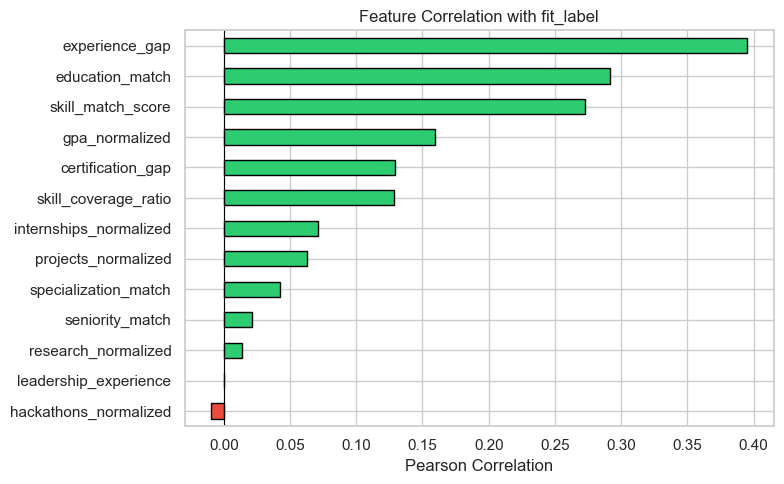

In [8]:
corr = model_df[feature_cols + ["fit_label"]].corr()["fit_label"].drop("fit_label").sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
corr.plot(kind="barh", ax=ax,
          color=["#e74c3c" if v < 0 else "#2ecc71" for v in corr.values],
          edgecolor="black")
ax.set_title("Feature Correlation with fit_label")
ax.set_xlabel("Pearson Correlation")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(ROOT / "screenshots/feature_correlation_with_label.png", dpi=150)
plt.show()

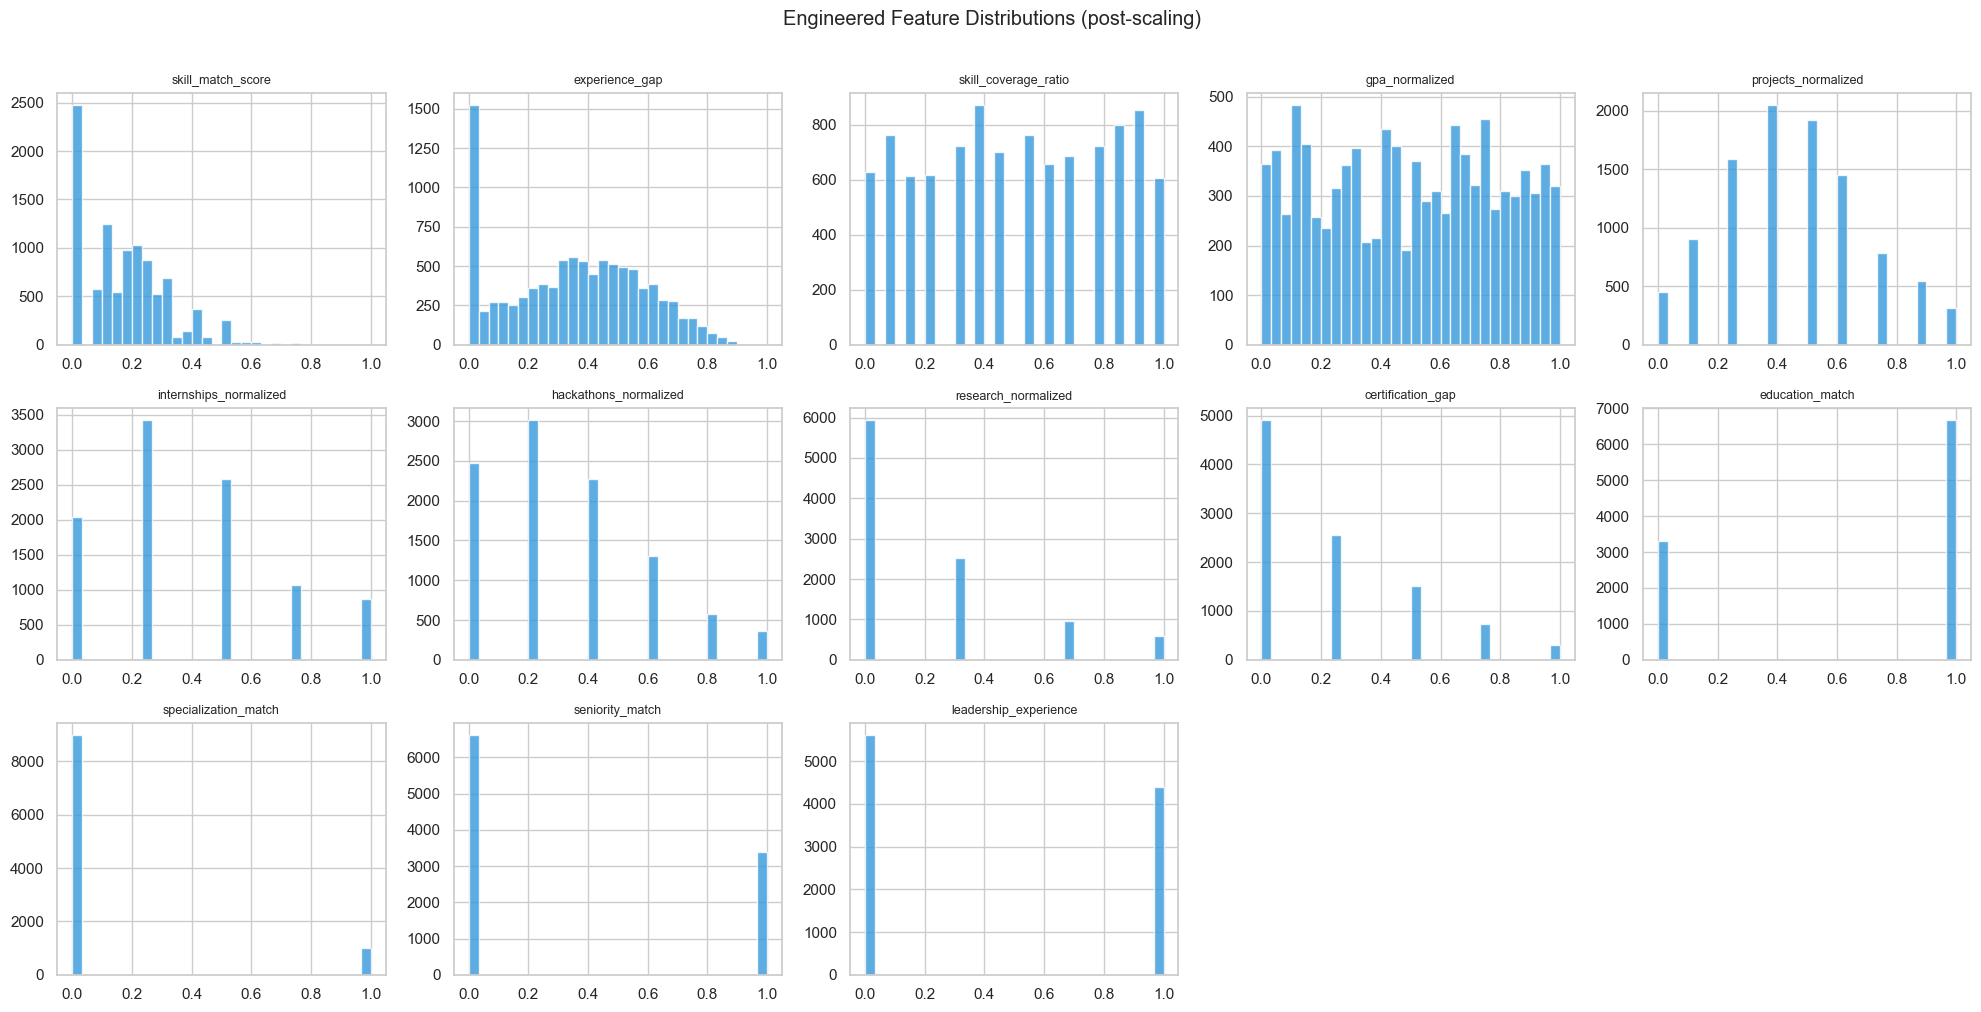

In [9]:
fig, axes = plt.subplots(3, 5, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(model_df[col], bins=30, color="#3498db",
                 edgecolor="white", alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Engineered Feature Distributions (post-scaling)", y=1.01)
plt.tight_layout()
plt.savefig(ROOT / "screenshots/feature_distributions.png", dpi=150)
plt.show()